# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?



## **Ответы на вопросы**

1. Разница между SAX и SFA: SAX упрощает с помощью кусочно-постоянных символов и берет за основу средние значения,
а SFA использует дискретные коэффициенты Фурье тем самым сохраняя частотную информацию. метод SFA лучше работает с зашумленными данными,
потому что Фурье сглаживает высокочастотный шум

2. алгоритм BOSS строит гистограммы встречаемости SFA-символов в подокнах ряда, потом применяет TF-IDF, чтобы взвесить редко встречающиеся
символы выше, таким образом получается выделить дискриминативные локальные паттерны, которые редко встречаются с других классах и снизить
влияние общих неинформативных признаков

3. shapelet это подпоследовательность временного ряда,наиболее характерная для определённого класса (фрагмент ряда в котором хорошо отражены св-ва ряда).
преимущество ROCKETа в том что он не ищет оптимальные шейплеты, а генерирует тысячи случайных свёрточных ядер, это на порядки быстрее и даёт
сравнимую или лучшую точность

4. начнем с того, что глубокая нейросеть как минимум требует много данных, времени обучения и тонкой настройки.
в то время как catch22 даёт интерпретируемые, а главное вычислительно дешёвые и устойчивые признаки, работающие на малых данных.
а еще её признаки CNN трудно интерпретировать

5. 1D-CNN эффективны, потому что автоматически выделяют локальные иерархические паттерны разного масштаба.
многоветвевые преобразования inception time позволяют одновременно использовать ядра разной длины в одном слое, захватывая и короткие,
и длинные зависимости без увеличения глубины сети

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


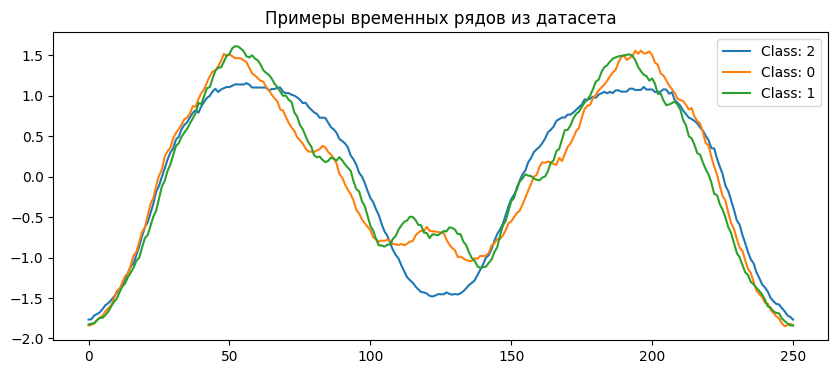

In [1]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [2]:
from sktime.classification.kernel_based import RocketClassifier
import time

# мой код здесь...

from sktime.classification.kernel_based import RocketClassifier
import time

# создание и обучение RocketClassifier
rocket = RocketClassifier(num_kernels=1000, random_state=42)

start = time.time()
rocket.fit(X_train, y_train)
rocket_train_time = time.time() - start

# предсказание и оценка качества
y_pred_rocket = rocket.predict(X_test)
rocket_acc = accuracy_score(y_test, y_pred_rocket)

print(f"ROCKET: Accuracy на тестовой выборке: {rocket_acc:.4f}")
print(f"ROCKET: Время обучения: {rocket_train_time:.2f} сек.")


ROCKET: Accuracy на тестовой выборке: 0.9219
ROCKET: Время обучения: 0.87 сек.


### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [3]:
from sktime.classification.dictionary_based import ContractableBOSS

# мой код здесь...

from sktime.classification.dictionary_based import ContractableBOSS

# создание и обучение ContractableBOSS
cboss = ContractableBOSS(n_parameter_samples=25, max_ensemble_size=10, random_state=42)

start = time.time()
cboss.fit(X_train, y_train)
cboss_train_time = time.time() - start

# предсказание и оценка качества
y_pred_cboss = cboss.predict(X_test)
cboss_acc = accuracy_score(y_test, y_pred_cboss)

print(f"ContracableBOSS: Accuracy на тестовой выборке: {cboss_acc:.4f}")
print(f"ContracableBOSS: Время обучения: {cboss_train_time:.2f} сек.")

# сравнение с ROCKET
print("Сравнение методов:")
print(f"{'Метод':<20} {'Accuracy':>10} {'Время обучения (с)':>20}")
print("-" * 52)
print(f"{'ROCKET':<20} {rocket_acc:>10.4f} {rocket_train_time:>20.2f}")
print(f"{'ContractableBOSS':<20} {cboss_acc:>10.4f} {cboss_train_time:>20.2f}")


ContracableBOSS: Accuracy на тестовой выборке: 0.9688
ContracableBOSS: Время обучения: 0.77 сек.
Сравнение методов:
Метод                  Accuracy   Время обучения (с)
----------------------------------------------------
ROCKET                   0.9219                 0.87
ContractableBOSS         0.9688                 0.77


### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [5]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

Epoch [5/30]  Loss: 0.6219
Epoch [10/30]  Loss: 0.4475
Epoch [15/30]  Loss: 0.2940
Epoch [20/30]  Loss: 0.2543
Epoch [25/30]  Loss: 0.1588
Epoch [30/30]  Loss: 0.1390
1D-CNN: Accuracy на тестовой выборке: 0.8438
1D-CNN: Время обучения: 1.10 сек.


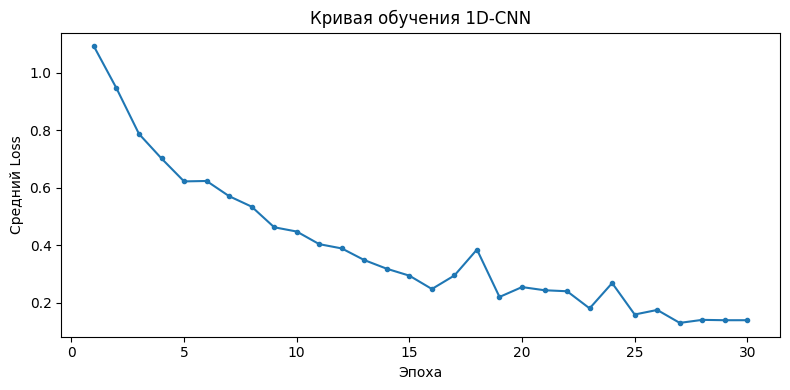

Итоговое сравнение методов
Метод                  Accuracy   Время обучения (с)
----------------------------------------------------
ROCKET                   0.9219                 0.87
ContractableBOSS         0.9688                 0.77
1D-CNN (PyTorch)         0.8438                 1.10


In [6]:
# 2. подготовка данных для PyTorch
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
num_classes = len(le.classes_)

X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train_enc)
y_test_t  = torch.LongTensor(y_test_enc)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 3. инициализация модели, функции потерь и оптимизатора
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Simple1DCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4. цикл обучения
EPOCHS = 30
train_losses = []

start = time.time()
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {avg_loss:.4f}")

cnn_train_time = time.time() - start

# 5. оценка на тестовой выборке
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_pred_cnn = logits.argmax(dim=1).cpu().numpy()

cnn_acc = accuracy_score(y_test_enc, y_pred_cnn)

print(f"1D-CNN: Accuracy на тестовой выборке: {cnn_acc:.4f}")
print(f"1D-CNN: Время обучения: {cnn_train_time:.2f} сек.")

# 6. график потерь
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", markersize=3)
plt.xlabel("Эпоха")
plt.ylabel("Средний Loss")
plt.title("Кривая обучения 1D-CNN")
plt.tight_layout()
plt.show()

# 7. итоговое сравнение всех трёх методов
print("Итоговое сравнение методов")
print(f"{'Метод':<20} {'Accuracy':>10} {'Время обучения (с)':>20}")
print("-" * 52)
print(f"{'ROCKET':<20} {rocket_acc:>10.4f} {rocket_train_time:>20.2f}")
print(f"{'ContractableBOSS':<20} {cboss_acc:>10.4f} {cboss_train_time:>20.2f}")
print(f"{'1D-CNN (PyTorch)':<20} {cnn_acc:>10.4f} {cnn_train_time:>20.2f}")